# Análise da Base SCR — Clientes Pessoa Física (PF)

Este notebook realiza uma análise exploratória da base de dados do SCR, com foco em **clientes Pessoa Física (PF)**.  
São analisadas características como ocupação, porte financeiro, modalidade de crédito, origem, indexador, número de operações e inadimplência.

In [16]:
import polars as pl
import matplotlib.pyplot as plt

## Leitura do arquivo CSV

Nesta etapa, o arquivo CSV selecionado é carregado utilizando a biblioteca **Polars**.  
O separador utilizado é `;`, conforme o padrão da base SCR.

In [ ]:
df = pl.read_csv("scrdata_.csv", separator=";")

cliente = df["cliente"].value_counts(sort=True)
print(cliente)


shape: (2, 2)
┌─────────┬────────┐
│ cliente ┆ count  │
│ ---     ┆ ---    │
│ str     ┆ u32    │
╞═════════╪════════╡
│ PF      ┆ 178255 │
│ PJ      ┆ 126045 │
└─────────┴────────┘


## Filtragem da base para clientes PF

A partir deste ponto, a análise passa a considerar **apenas clientes Pessoa Física (PF)**, filtrando a base original.

In [18]:
df_pf = df.filter(pl.col("cliente") == "PF")

## Distribuição por ocupação (CNAE)

Nesta etapa, analisamos a distribuição das ocupações dos clientes PF, utilizando a coluna `cnae_ocupacao`. A informação é proveniente do cadastro da Receita Federal do Brasil e refere-se à natureza da ocupação principal.

O gráfico mostra quais ocupações aparecem com maior frequência na base.

shape: (8, 2)
┌─────────────────────────────────┬───────┐
│ cnae_ocupacao                   ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Outros                          ┆ 30554 │
│ Empresário                      ┆ 26767 │
│ Empregado de empresa privada    ┆ 25515 │
│ Autônomo                        ┆ 25056 │
│ Servidor ou empregado público   ┆ 24797 │
│ Aposentado/pensionista          ┆ 20573 │
│ MEI                             ┆ 16707 │
│ Empregado de entidades sem fin… ┆ 8286  │
└─────────────────────────────────┴───────┘


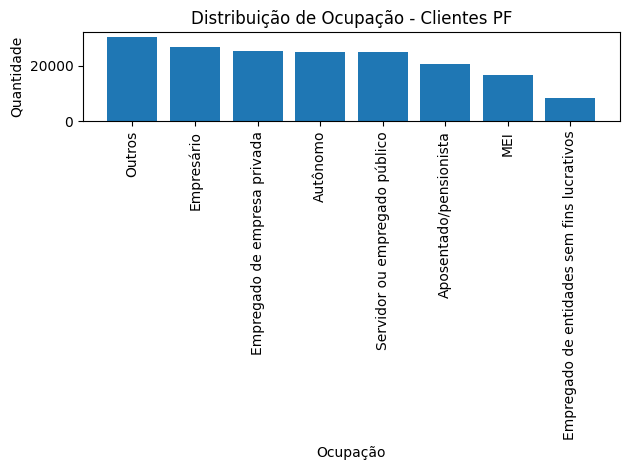

In [19]:

ocupacao = df_pf["cnae_ocupacao"].value_counts(sort=True)
print(ocupacao)

plt.figure()
plt.bar(
    ocupacao["cnae_ocupacao"].to_list(),
    ocupacao["count"].to_list()
)

plt.xticks(rotation=90)
plt.xlabel("Ocupação")
plt.ylabel("Quantidade")
plt.title("Distribuição de Ocupação - Clientes PF")
plt.tight_layout()
plt.show()

## Porte financeiro dos clientes PF

Aqui avaliamos a distribuição dos clientes PF por **porte financeiro**, permitindo visualizar a concentração em cada categoria.

O porte dos clientes está agrupado da seguinte forma:
- PF - Sem rendimento
- PF - Até 1 salário-mínimo
- PF - Mais de 1 a 2 salários-mínimos
- PF - Mais de 2 a 3 salários-mínimos
- PF - Mais de 3 a 5 salários-mínimos
- PF - Mais de 5 a 10 salários-mínimos
- PF - Mais de 10 a 20 salários-mínimos
- PF - Acima de 20 salários-mínimos
- PF - Indisponível

shape: (9, 2)
┌─────────────────────────────────┬───────┐
│ porte                           ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Mais de 5 a 10 salários mínimo… ┆ 24099 │
│ Mais de 3 a 5 salários mínimos  ┆ 23516 │
│ Mais de 1 a 2 salários mínimos  ┆ 23246 │
│ Mais de 10 a 20 salários mínim… ┆ 22130 │
│ Acima de 20 salários mínimos    ┆ 22085 │
│ Mais de 2 a 3 salários mínimos  ┆ 21855 │
│ Até 1 salário mínimo            ┆ 19065 │
│ Indisponível                    ┆ 14061 │
│ Sem rendimento                  ┆ 8198  │
└─────────────────────────────────┴───────┘


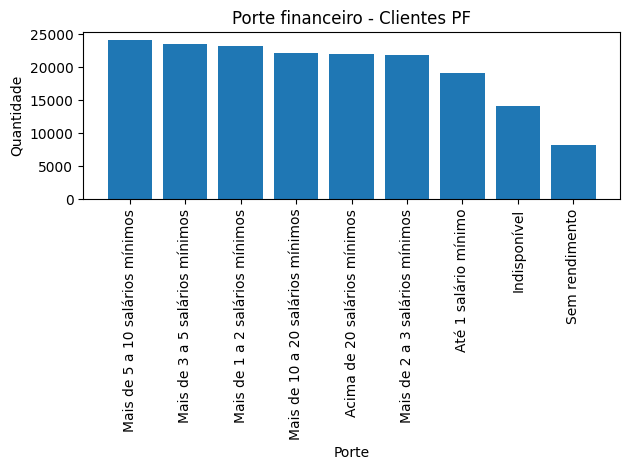

In [20]:
porte = df_pf["porte"].value_counts(sort=True)

print(porte)

plt.figure()
plt.bar(
    porte["porte"].to_list(),
    porte["count"].to_list()
)

plt.xticks(rotation=90)
plt.xlabel("Porte")
plt.ylabel("Quantidade")
plt.title("Porte financeiro - Clientes PF")
plt.tight_layout()
plt.show()

## Modalidade de crédito — Clientes PF

Esta análise apresenta as diferentes **modalidades de crédito** associadas aos clientes PF, indicando quais são mais comuns.

shape: (13, 2)
┌─────────────────────────────────┬───────┐
│ modalidade                      ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Empréstimos                     ┆ 82577 │
│ Financiamentos                  ┆ 29091 │
│ Outros créditos                 ┆ 24265 │
│ Financiamentos rurais  (ex-fin… ┆ 19590 │
│ Financiamentos imobiliários     ┆ 15170 │
│ …                               ┆ …     │
│ Financiamentos à exportação     ┆ 213   │
│ Financiamentos de títulos e va… ┆ 145   │
│ Financiamentos com interveniên… ┆ 66    │
│ Financiamentos de infraestrutu… ┆ 9     │
│ Financiamentos à importação     ┆ 1     │
└─────────────────────────────────┴───────┘


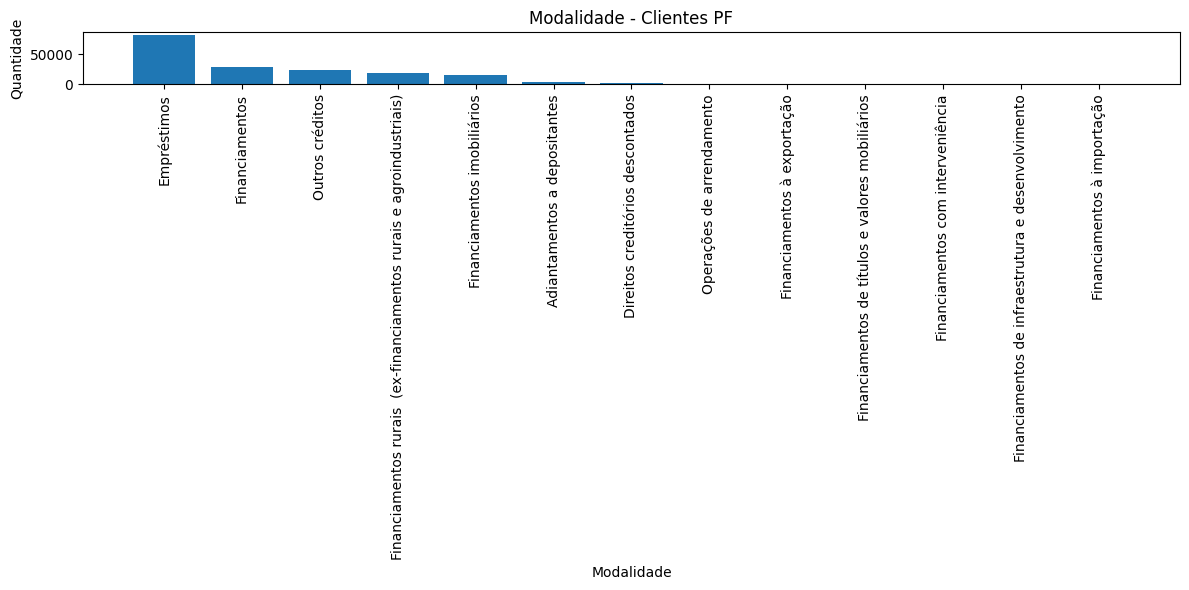

In [21]:
modalidade = df_pf["modalidade"].value_counts(sort=True)

print(modalidade)

plt.figure(figsize=(12, 6))
plt.bar(
    modalidade["modalidade"].to_list(),
    modalidade["count"].to_list()
)

plt.xticks(rotation=90)
plt.xlabel("Modalidade")
plt.ylabel("Quantidade")
plt.title("Modalidade - Clientes PF")
plt.tight_layout()
plt.show()

## Origem das operações de crédito

Neste gráfico, observamos a **origem das operações** contratadas pelos clientes PF.

A origem dos recursos está agrupada da seguinte forma:
- Sem destinação específica
- Com destinação específica

shape: (2, 2)
┌───────────────────────────┬────────┐
│ origem                    ┆ count  │
│ ---                       ┆ ---    │
│ str                       ┆ u32    │
╞═══════════════════════════╪════════╡
│ Sem destinação específica ┆ 144991 │
│ Com destinação específica ┆ 33264  │
└───────────────────────────┴────────┘


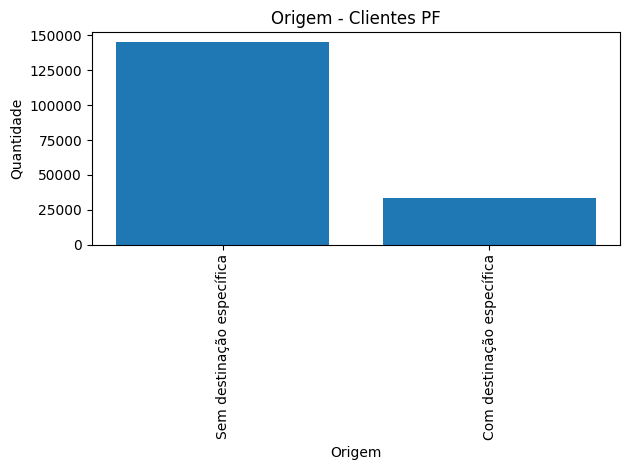

In [22]:
origem = df_pf["origem"].value_counts(sort=True)

print(origem)

plt.figure()
plt.bar(
    origem["origem"].to_list(),
    origem["count"].to_list()
)

plt.xticks(rotation=90)
plt.xlabel("Origem")
plt.ylabel("Quantidade")
plt.title("Origem - Clientes PF")
plt.tight_layout()
plt.show()

## Indexadores das operações

Aqui analisamos quais **indexadores** são mais utilizados nas operações de crédito dos clientes PF.

Os indexadores da operação estão agrupados da seguinte forma:

- Prefixado
- Pós-fixado
- Flutuantes
- Índices de preços
- TCR/TRFC
- Outros indexadores

*TCR/TRFC: Taxas de Juros do Crédito Rural e Taxas de Juros Rurais dos Fundos Constitucionais de
Financiamento.

shape: (6, 2)
┌────────────────────┬────────┐
│ indexador          ┆ count  │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ Prefixado          ┆ 114347 │
│ Pós-fixado         ┆ 26255  │
│ Flutuantes         ┆ 14855  │
│ Outros indexadores ┆ 13049  │
│ Índices de preços  ┆ 7184   │
│ TCR/TRFC           ┆ 2565   │
└────────────────────┴────────┘


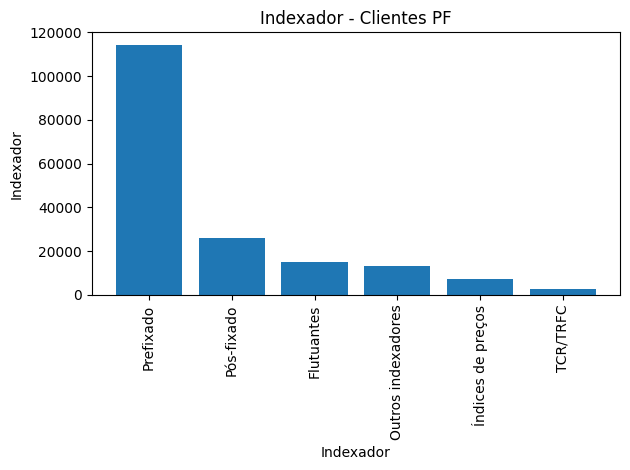

In [23]:
indexador = df_pf["indexador"].value_counts(sort=True)

print(indexador)

plt.figure()
plt.bar(
    indexador["indexador"].to_list(),
    indexador["count"].to_list()
)

plt.xticks(rotation=90)
plt.xlabel("Indexador")
plt.ylabel("Indexador")
plt.title("Indexador - Clientes PF")
plt.tight_layout()
plt.show()

## Tratamento do número de operações

A coluna `numero_de_operacoes` é convertida para o tipo inteiro, criando uma nova coluna (`num_op`) para facilitar análises quantitativas.

Representa o número de operações de crédito para uma dada série.

In [24]:
df_pf = df_pf.with_columns(
    pl.col("numero_de_operacoes")
      .cast(pl.Int64)
      .alias("num_op")
)

### Criação de faixas de número de operações

Nesta etapa, os clientes PF são agrupados em **faixas de número de operações**, facilitando a visualização da distribuição:

- 0  
- 1–15  
- 16–30  
- 31–60  
- 61–90  
- 90+

In [25]:
df_pf = df_pf.with_columns(
    pl.when(pl.col("num_op") <= 0).then(pl.lit("0"))
    .when(pl.col("num_op") <= 15).then(pl.lit("1-15"))
    .when(pl.col("num_op") <= 30).then(pl.lit("16-30"))
    .when(pl.col("num_op") <= 60).then(pl.lit("31-60"))
    .when(pl.col("num_op") <= 90).then(pl.lit("61-90"))
    .otherwise(pl.lit("90+"))
    .alias("faixa_operacoes")
)

### Distribuição de clientes por faixa de operações

O gráfico abaixo mostra a quantidade de clientes PF em cada faixa de número de operações.

In [26]:
faixas = (
    df_pf["faixa_operacoes"]
    .value_counts(sort=True)
)

print(faixas)

shape: (6, 2)
┌─────────────────┬───────┐
│ faixa_operacoes ┆ count │
│ ---             ┆ ---   │
│ str             ┆ u32   │
╞═════════════════╪═══════╡
│ 1-15            ┆ 56744 │
│ 90+             ┆ 53662 │
│ 0               ┆ 35201 │
│ 16-30           ┆ 13659 │
│ 31-60           ┆ 12384 │
│ 61-90           ┆ 6605  │
└─────────────────┴───────┘


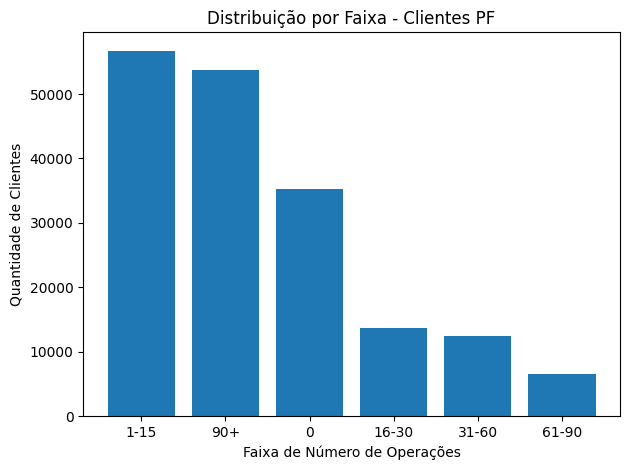

In [27]:
plt.figure()
plt.bar(
    faixas["faixa_operacoes"].to_list(),
    faixas["count"].to_list()
)

plt.xlabel("Faixa de Número de Operações")
plt.ylabel("Quantidade de Clientes")
plt.title("Distribuição por Faixa - Clientes PF")
plt.tight_layout()
plt.show()

## Análise de inadimplência — Clientes PF

Nesta etapa, a coluna `carteira_vencida` é tratada e convertida para valor numérico.
Com base nesse valor, é criado um **status de inadimplência**:

- **Inadimplente**: valor vencido maior que zero  
- **Adimplente**: sem valor vencido

shape: (2, 2)
┌──────────────────────┬────────┐
│ status_inadimplencia ┆ count  │
│ ---                  ┆ ---    │
│ str                  ┆ u32    │
╞══════════════════════╪════════╡
│ Inadimplente         ┆ 104118 │
│ Adimplente           ┆ 74137  │
└──────────────────────┴────────┘


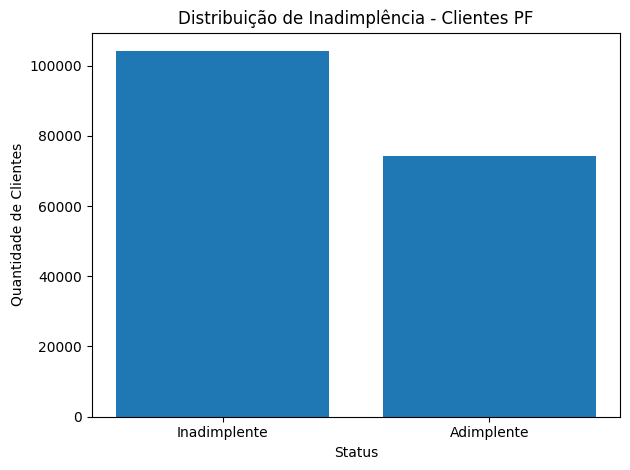

In [28]:
df_pf = df_pf.with_columns(
    pl.col("carteira_vencida")
    .str.replace(",", ".")
    .cast(pl.Float64, strict=False)
    .fill_null(0)
    .alias("vencido_valor")
)

df_pf = df_pf.with_columns(
    pl.when(pl.col("vencido_valor") > 0)
    .then(pl.lit("Inadimplente"))
    .otherwise(pl.lit("Adimplente"))
    .alias("status_inadimplencia")
)

status = df_pf["status_inadimplencia"].value_counts()

print(status)

# Gráfico
plt.figure()
plt.bar(
    status["status_inadimplencia"].to_list(),
    status["count"].to_list()
)

plt.xlabel("Status")
plt.ylabel("Quantidade de Clientes")
plt.title("Distribuição de Inadimplência - Clientes PF")
plt.tight_layout()
plt.show()
